<a href="https://colab.research.google.com/github/Anton-maxi/pattern-recognition-practice/blob/main/notebooks/PR03_Zboryk_Anton.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практична робота 3

## Перша модель і базове оцінювання якості

**Дисципліна:** Розпізнавання образів і машинне навчання

**Студент:** Зборик Антон

**Група:** ІН-42/2

**Дата виконання:** 02.10.2026

### Мета роботи

Побудувати першу завершену модель машинного навчання,
отримати прогнози та навчитися оцінювати їхню якість
за допомогою основних метрик класифікації.

## 1. Підключення бібліотек

In [39]:
from pathlib import Path

import joblib
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay
)

from IPython.display import display

In [40]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [41]:
PROJECT_DIR = Path(
    "/content/drive/MyDrive/3_course/Image_Recognition_and_Classical_Machine_Learning"
)

DATA_PATH = (
    PROJECT_DIR
    / "data"
    / "processed"
    / "iris_cleaned.csv"
)

MODELS_DIR = PROJECT_DIR / "models"
REPORTS_DIR = PROJECT_DIR / "reports"

MODEL_PATH = MODELS_DIR / "iris_decision_tree.joblib"
METRICS_PATH = REPORTS_DIR / "model_metrics.csv"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("Файл даних:", DATA_PATH)
print("Файл моделі:", MODEL_PATH)

Файл даних: /content/drive/MyDrive/3_course/Image_Recognition_and_Classical_Machine_Learning/data/processed/iris_cleaned.csv
Файл моделі: /content/drive/MyDrive/3_course/Image_Recognition_and_Classical_Machine_Learning/models/iris_decision_tree.joblib


## 2. Завантаження підготовленого набору даних

In [42]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        "Файл iris_cleaned.csv не знайдено. "
        "Перевірте виконання практичної роботи 2."
    )

data = pd.read_csv(DATA_PATH)

display(data.head())

,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,species,measurement_device
0,5.1,3.5,1.4,0.2,setosa,device_c
1,5.8,3.0,1.4,0.2,setosa,device_b
2,4.7,3.2,1.3,0.2,setosa,device_c
3,5.1,3.1,1.5,0.2,setosa,device_b
4,5.0,3.6,1.4,0.2,setosa,device_a


In [43]:
print("Розмір таблиці:", data.shape)
print("\nТипи даних:")
print(data.dtypes)

print(
    "\nКількість пропусків:",
    data.isna().sum().sum()
)

Розмір таблиці: (148, 6)

Типи даних:
sepal_length_cm       float64
sepal_width_cm        float64
petal_length_cm       float64
petal_width_cm        float64
species                object
measurement_device     object
dtype: object

Кількість пропусків: 0


1. 148
2. 4 числових ознак та 1 категоріальна ознака (measurement_device)
3. Ні
4. species

In [44]:
X = data.drop(columns=["species"])
y = data["species"]

categorical_columns = X.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

print(
    "Категоріальні ознаки:",
    categorical_columns
)

Категоріальні ознаки: ['measurement_device']


In [45]:
X = pd.get_dummies(
    X,
    columns=categorical_columns,
    dtype=int
)

display(X.head())

,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,measurement_device_device_a,measurement_device_device_b,measurement_device_device_c
0,5.1,3.5,1.4,0.2,0,0,1
1,5.8,3.0,1.4,0.2,0,1,0
2,4.7,3.2,1.3,0.2,0,0,1
3,5.1,3.1,1.5,0.2,0,1,0
4,5.0,3.6,1.4,0.2,1,0,0


In [46]:
print("Розмір X:", X.shape)
print("Розмір y:", y.shape)

Розмір X: (148, 7)
Розмір y: (148,)


In [47]:
X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )
)

In [48]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (118, 7)
X_test: (30, 7)
y_train: (118,)
y_test: (30,)


In [49]:
split_distribution = pd.DataFrame(
    {
        "train_percent": (
            y_train
            .value_counts(normalize=True)
            .sort_index()
            .mul(100)
            .round(2)
        ),
        "test_percent": (
            y_test
            .value_counts(normalize=True)
            .sort_index()
            .mul(100)
            .round(2)
        )
    }
)

display(split_distribution)

,train_percent,test_percent
species,,
setosa,33.90,33.33
versicolor,33.05,33.33
virginica,33.05,33.33


1. **Чому тестова вибірка не використовується для навчання?**
Тест потрібен, щоб перевірити модель на даних, яких вона ніколи не бачила. Якби модель навчалася на тестових даних, вона б підлаштовувалась під них, а не розпізнавала закономірності, і оцінка на тесті вийшла б завищеною та не показала б справжню якість роботи з новими об'єктами.

2. **Для чого встановлено `random_state=42`?**
Перед поділом `train_test_split` випадково перемішує рядки. Параметр `random_state` задає стартове число для цього перемішування, тому при кожному запуску поділ однаковий і в тест потрапляють ті самі 30 об'єктів. Це робить результати відтворюваними: їх можна порівнювати між запусками, і інша людина отримає ті самі числа. Саме значення 42 довільне, підійшло б будь-яке число.

3. **Для чого використовується `stratify=y`?**
Параметр зберігає в навчальній і тестовій вибірках ті самі частки класів, що й у всьому наборі. Завдяки цьому в тесті по 10 об'єктів кожного виду, а в навчальній вибірці 40 `setosa` і по 39 `versicolor` та `virginica`. Без стратифікації випадковий поділ міг би дати перекіс, наприклад майже без одного з видів у тесті.

4. **Чи близькі частки класів у train і test?**
Так, частки дуже близькі, майже рівні. Для `setosa` це 33,90 % у навчальній вибірці та 33,33 % у тестовій, для `versicolor` і `virginica` по 33,05 % та 33,33 %. Найбільша різниця становить приблизно 0,57 відсоткового пункта.

## 3. Базова модель DummyClassifier

DummyClassifier використовується як найпростіший орієнтир.
Він не аналізує ознаки та прогнозує найпоширеніший клас.

In [50]:
dummy_model = DummyClassifier(
    strategy="most_frequent"
)

In [51]:
dummy_model.fit(
    X_train,
    y_train
)

DummyClassifier(strategy='most_frequent')

In [52]:
dummy_train_predictions = dummy_model.predict(
    X_train
)

dummy_test_predictions = dummy_model.predict(
    X_test
)

In [53]:
dummy_preview = pd.DataFrame(
    {
        "actual": y_test.iloc[:10].values,
        "predicted": dummy_test_predictions[:10]
    }
)

display(dummy_preview)

,actual,predicted
0,versicolor,setosa
1,versicolor,setosa
2,virginica,setosa
3,setosa,setosa
4,virginica,setosa
5,versicolor,setosa
6,versicolor,setosa
7,setosa,setosa
8,virginica,setosa
9,virginica,setosa


### Відповіді до базової моделі

DummyClassifier завжди прогнозує клас `setosa`, тому що це найпоширеніший клас у навчальній вибірці (40 об'єктів проти 39 в інших класів). Така модель не може вважатися достатньою, бо вона не аналізує ознаки, а лише повторює найчастіший вид. У перших 10 прогнозах вона вгадала лише 2 об'єкти, які справді були `setosa`, а `versicolor` і `virginica` не розпізнала жодного разу.

## 4. Дерево рішень

Будується дерево рішень з обмеженою максимальною глибиною.

In [54]:
tree_model = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

In [55]:
tree_model.fit(
    X_train,
    y_train
)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [56]:
tree_train_predictions = tree_model.predict(
    X_train
)

tree_test_predictions = tree_model.predict(
    X_test
)

In [57]:
prediction_preview = pd.DataFrame(
    {
        "actual": y_test.iloc[:15].values,
        "predicted": tree_test_predictions[:15]
    }
)

prediction_preview["correct"] = (
    prediction_preview["actual"]
    == prediction_preview["predicted"]
)

display(prediction_preview)

,actual,predicted,correct
0,versicolor,versicolor,True
1,versicolor,versicolor,True
2,virginica,virginica,True
3,setosa,setosa,True
4,virginica,virginica,True
5,versicolor,versicolor,True
6,versicolor,versicolor,True
7,setosa,setosa,True
8,virginica,virginica,True
9,virginica,virginica,True


### Відповідь до дерева рішень

З перших 15 прогнозів дерева рішень правильні всі 15: у колонці `correct` скрізь значення `True`. Це лише перші 15 об'єктів із 30 у тесті, тому повну якість моделі покажуть метрики на всій тестовій вибірці.

In [58]:
def calculate_metrics(
    model_name,
    dataset_name,
    y_true,
    y_pred
):
    """
    Обчислює основні метрики багатокласової класифікації.
    """
    return {
        "model": model_name,
        "dataset": dataset_name,
        "accuracy": accuracy_score(
            y_true,
            y_pred
        ),
        "precision_macro": precision_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "recall_macro": recall_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "f1_macro": f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        )
    }

In [59]:
metrics_rows = [
    calculate_metrics(
        "DummyClassifier",
        "train",
        y_train,
        dummy_train_predictions
    ),
    calculate_metrics(
        "DummyClassifier",
        "test",
        y_test,
        dummy_test_predictions
    ),
    calculate_metrics(
        "DecisionTree",
        "train",
        y_train,
        tree_train_predictions
    ),
    calculate_metrics(
        "DecisionTree",
        "test",
        y_test,
        tree_test_predictions
    )
]

metrics_df = pd.DataFrame(metrics_rows)

display(
    metrics_df.round(3)
)

,model,dataset,accuracy,precision_macro,recall_macro,f1_macro
0,DummyClassifier,train,0.339,0.113,0.333,0.169
1,DummyClassifier,test,0.333,0.111,0.333,0.167
2,DecisionTree,train,0.983,0.984,0.983,0.983
3,DecisionTree,test,0.933,0.936,0.933,0.933


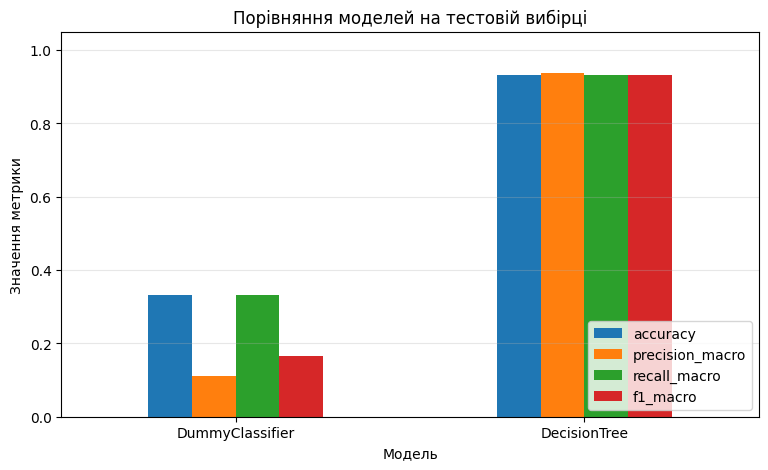

In [60]:
test_metrics = (
    metrics_df[
        metrics_df["dataset"] == "test"
    ]
    .set_index("model")
)

test_metrics[
    [
        "accuracy",
        "precision_macro",
        "recall_macro",
        "f1_macro"
    ]
].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title(
    "Порівняння моделей на тестовій вибірці"
)

plt.xlabel("Модель")
plt.ylabel("Значення метрики")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.legend(
    loc="lower right"
)
plt.show()

### Відповіді до порівняння моделей

1. Найвищу accuracy має DecisionTree: 0.933 проти 0.333 у DummyClassifier.

2. Найвищу F1-міру також має DecisionTree: 0.933 проти 0.167 у DummyClassifier.

3. Дерево рішень перевищує DummyClassifier за всіма метриками. Accuracy і recall_macro вищі на 0.600, тобто приблизно в 2.8 раза. F1-міра вища приблизно на 0.77, тобто приблизно в 5.6 раза. Precision_macro вища приблизно на 0.83, тобто приблизно в 8.4 раза.

4. Лише за accuracy оцінювати модель недостатньо, тому що вона показує загальну частку правильних відповідей і не говорить, які саме класи модель не розпізнає. У DummyClassifier accuracy становить 0.333, але precision_macro лише 0.111, а F1-міра 0.167: модель знаходить тільки один клас із трьох, а два інші не прогнозує жодного разу. Precision, recall і F1-міра рахуються по кожному класу окремо, тому показують такі помилки. Особливо небезпечно покладатися на accuracy, коли один клас значно більший за інші: тоді модель може прогнозувати лише його й усе одно мати високу accuracy.

In [61]:
train_test_comparison = metrics_df.pivot(
    index="model",
    columns="dataset",
    values=[
        "accuracy",
        "f1_macro"
    ]
)

display(
    train_test_comparison.round(3)
)

accuracy        f1_macro       
dataset             test  train     test  train
model                                          
DecisionTree       0.933  0.983    0.933  0.983
DummyClassifier    0.333  0.339    0.167  0.169

In [62]:
tree_train_accuracy = accuracy_score(
    y_train,
    tree_train_predictions
)

tree_test_accuracy = accuracy_score(
    y_test,
    tree_test_predictions
)

accuracy_gap = (
    tree_train_accuracy
    - tree_test_accuracy
)

print(
    "Accuracy на train:",
    round(tree_train_accuracy, 3)
)

print(
    "Accuracy на test:",
    round(tree_test_accuracy, 3)
)

print(
    "Різниця:",
    round(accuracy_gap, 3)
)

Accuracy на train: 0.983
Accuracy на test: 0.933
Різниця: 0.05


### Відповіді до порівняння train і test

1. **Чи недонавчений DummyClassifier?**
Так, DummyClassifier недонавчений. Його якість низька і на навчальній, і на тестовій вибірці: accuracy 0.339 на train і 0.333 на test, F1-міра 0.169 і 0.167. Результати майже однакові й незадовільні, бо модель не аналізує ознаки, а завжди прогнозує найпоширеніший клас `setosa`.

2. **Чи є ознаки перенавчання дерева?**
Ні, суттєвих ознак перенавчання немає. Accuracy дерева на train становить 0.983, на test 0.933, різниця лише 0.05. F1-міра така сама: 0.983 і 0.933. Якість на тесті лише трохи нижча, ніж на train, а не помітно гірша, тому модель не запам'ятала навчальні дані. До того ж тестова вибірка мала (30 об'єктів), і одна помилка змінює accuracy приблизно на 0.033.

3. **Чи має дерево прийнятну узагальнювальну здатність?**
Так, має. Accuracy і F1-міра на тестовій вибірці дорівнюють 0.933, тобто модель добре працює на об'єктах, яких не бачила під час навчання. Це значно вище за DummyClassifier (0.333 та 0.167). Розрив між train і test невеликий, лише 0.05. Усі три ознаки хорошої узагальнювальної здатності виконуються.

## 5. Матриця помилок

Матриця помилок показує, які класи модель визначає правильно,
а які плутає між собою.

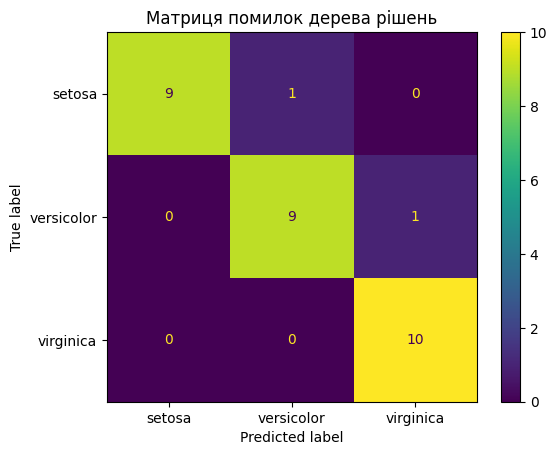

In [63]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    tree_test_predictions
)

plt.title(
    "Матриця помилок дерева рішень"
)

plt.show()

### Відповіді до матриці помилок

1. Правильно класифіковано 28 об'єктів із 30: на головній діагоналі 9 для `setosa`, 9 для `versicolor` і 10 для `virginica`.

2. Без помилок розпізнається `virginica`: усі 10 її об'єктів класифіковано правильно. `setosa` і `versicolor` розпізнано майже без помилок, по 9 із 10.

3. Помилок лише дві, і кожна пара змішана один раз: один об'єкт `setosa` модель назвала `versicolor`, а один об'єкт `versicolor` назвала `virginica`. Виразного лідера немає, але `versicolor` бере участь в обох помилках.

4. Помилка між `versicolor` і `virginica` узгоджується з діаграмами попередньої роботи, де ці два види перекривалися. Помилка для `setosa` суперечить діаграмам, бо цей вид був чітко відокремлений. Причину дає аналіз помилкових прогнозів нижче.

In [64]:
test_results = X_test.copy()

test_results["actual"] = y_test.values
test_results["predicted"] = tree_test_predictions

test_results["correct"] = (
    test_results["actual"]
    == test_results["predicted"]
)

In [65]:
mistakes = test_results[
    ~test_results["correct"]
]

display(mistakes)

,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,measurement_device_device_a,measurement_device_device_b,measurement_device_device_c,actual,predicted,correct
10,5.4,3.7,4.3,0.2,1,0,0,setosa,versicolor,False
77,6.7,3.0,5.0,1.7,0,1,0,versicolor,virginica,False


In [66]:
print(
    "Кількість помилкових прогнозів:",
    len(mistakes)
)

Кількість помилкових прогнозів: 2


### Аналіз помилкових прогнозів

Модель помилилася на двох тестових об'єктах із 30.

**Помилка 1.** Справжній клас `setosa`, прогноз `versicolor`. Значення ознак: довжина чашолистка 5.4, ширина чашолистка 3.7, довжина пелюстки 4.3, ширина пелюстки 0.2. Типова довжина пелюстки `setosa` у даних 1.3–1.5, а 4.3 характерна для `versicolor`. Це значення збігається з медіаною, якою ми заповнювали пропущені й аномальні значення довжини пелюстки в практичній роботі 2, тому, імовірно, помилку спричинило саме заповнення медіаною всієї колонки, а не реальний вимір цього об'єкта. Решта ознак об'єкта типові для `setosa`.

**Помилка 2.** Справжній клас `versicolor`, прогноз `virginica`. Значення ознак: довжина чашолистка 6.7, ширина чашолистка 3.0, довжина пелюстки 5.0, ширина пелюстки 1.7. Розміри пелюстки великі для `versicolor` і невеликі для `virginica`, тобто об'єкт лежить у зоні, де ці два види перекриваються.

Тестова вибірка містить лише 30 об'єктів, тому кожна помилка змінює accuracy приблизно на 0.033. Через це результат може помітно залежати від того, які саме об'єкти потрапили в тест при випадковому розбитті.

## 6. Збереження навченої моделі

Модель зберігається разом із назвами ознак, щоб її можна було
правильно використати в наступних роботах.

In [67]:
model_bundle = {
    "model": tree_model,
    "feature_columns": X.columns.tolist(),
    "target_classes": sorted(
        y.unique().tolist()
    )
}

In [68]:
joblib.dump(
    model_bundle,
    MODEL_PATH
)

print(
    "Модель збережено:",
    MODEL_PATH
)

Модель збережено: /content/drive/MyDrive/3_course/Image_Recognition_and_Classical_Machine_Learning/models/iris_decision_tree.joblib


In [69]:
loaded_bundle = joblib.load(
    MODEL_PATH
)

loaded_model = loaded_bundle["model"]

print(
    "Ознаки моделі:",
    loaded_bundle["feature_columns"]
)

print(
    "Класи:",
    loaded_bundle["target_classes"]
)

Ознаки моделі: ['sepal_length_cm', 'sepal_width_cm', 'petal_length_cm', 'petal_width_cm', 'measurement_device_device_a', 'measurement_device_device_b', 'measurement_device_device_c']
Класи: ['setosa', 'versicolor', 'virginica']


In [70]:
one_object = X_test.iloc[[0]]

loaded_prediction = loaded_model.predict(
    one_object
)

print(
    "Справжній клас:",
    y_test.iloc[0]
)

print(
    "Прогноз моделі:",
    loaded_prediction[0]
)

Справжній клас: versicolor
Прогноз моделі: versicolor


In [71]:
metrics_df.to_csv(
    METRICS_PATH,
    index=False
)

print(
    "Таблицю метрик збережено:",
    METRICS_PATH
)

Таблицю метрик збережено: /content/drive/MyDrive/3_course/Image_Recognition_and_Classical_Machine_Learning/reports/model_metrics.csv


In [72]:
assert X_train.isna().sum().sum() == 0, (
    "У X_train залишилися пропуски."
)

assert X_test.isna().sum().sum() == 0, (
    "У X_test залишилися пропуски."
)

assert len(tree_test_predictions) == len(y_test), (
    "Кількість прогнозів не відповідає "
    "кількості тестових об'єктів."
)

assert set(tree_test_predictions).issubset(
    set(y_train.unique())
), "Модель прогнозує невідомий клас."

assert MODEL_PATH.exists(), (
    "Файл моделі не збережено."
)

assert tree_test_accuracy > accuracy_score(
    y_test,
    dummy_test_predictions
), (
    "Дерево не перевищує базову модель. "
    "Перевірте підготовку даних."
)

print(
    "Усі основні перевірки виконано успішно."
)

Усі основні перевірки виконано успішно.


# Висновки

Під час виконання практичної роботи було побудовано перші моделі машинного навчання для класифікації об'єктів набору Iris.

Як базовий орієнтир використано DummyClassifier, який завжди прогнозував найпоширеніший клас. Його результати показали рівень якості, який повинна перевищувати реальна модель.

Як основну модель побудовано дерево рішень із максимальною глибиною 3. Модель було навчено на навчальній вибірці, після чого отримано прогнози для навчальних і тестових даних.

Якість моделей оцінено за accuracy, precision, recall і F1-мірою. Дерево рішень показало кращі результати порівняно з базовою моделлю, що підтверджує наявність закономірностей між ознаками квітки та її видом.

За допомогою матриці помилок було визначено, які класи модель розпізнає правильно та які класи вона може плутати. Порівняння результатів на навчальній і тестовій вибірках дало змогу оцінити узагальнювальну здатність моделі.


### Конкретні результати

- Accuracy DummyClassifier на тестовій вибірці: 0.333.
- Accuracy дерева рішень на навчальній вибірці: 0.983.
- Accuracy дерева рішень на тестовій вибірці: 0.933.
- F1-міра дерева рішень на тестовій вибірці: 0.933.
- Різниця accuracy між навчальною і тестовою вибірками: 0.05.
- Кількість помилкових прогнозів на тесті: 2 з 30.
- Класи, які модель плутає: `setosa` з `versicolor` (один об'єкт, ймовірно через значення довжини пелюстки, заповнене медіаною) і `versicolor` з `virginica` (один об'єкт у зоні перекриття цих видів).
- DummyClassifier недонавчений, бо має низьку якість і на навчальній, і на тестовій вибірці. У дерева рішень немає суттєвих ознак перенавчання: якість висока на обох вибірках, а різниця між ними невелика. Модель має прийнятну узагальнювальну здатність.